# Reading Planetary Computer COGs with async-geotiff

This notebook walks through pixel-level Cloud Optimized GeoTIFF reads with [async-geotiff](https://github.com/developmentseed/async-geotiff). async-geotiff is a Python COG reader with a Rust core, no GDAL dependency, and an async-first API. 

The companion [async-geotiff tutorial](../overview/async-geotiff.md) has the full narrative and the migration notes.

## Install

In [1]:
%pip install --quiet async-geotiff obstore lonboard planetary-computer pystac-client matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Find a Sentinel-2 scene

`modifier=planetary_computer.sign_inplace` signs every asset href as the search returns.

**Expected result:** a printed asset href pointing at the Sentinel-2 `visual` COG on Azure Blob.

In [2]:
import pystac_client
import planetary_computer

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
item = next(catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[-122.7, 45.5, -122.6, 45.6],
    datetime="2024-07-01/2024-08-01",
    query={"eo:cloud_cover": {"lt": 10}},
    max_items=1,
).items())

asset = item.assets["visual"]
asset.href.split("?")[0]  # drop the SAS token query string

'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/10/T/ER/2024/07/23/S2B_MSIL2A_20240723T190919_N0511_R056_T10TER_20240723T233135.SAFE/GRANULE/L2A_T10TER_A038549_20240723T191249/IMG_DATA/R10m/T10TER_20240723T190919_TCI_10m.tif'

## Build an authenticated obstore store

async-geotiff reads bytes through an obstore store. `PlanetaryComputerCredentialProvider.from_asset` figures out the account and container and mounts the store to this single blob so the COG is opened with an empty path in the next cell.

**Expected result:** working `store` object, no output printed.

In [3]:
from obstore.auth.planetary_computer import PlanetaryComputerCredentialProvider
from obstore.store import AzureStore

provider = PlanetaryComputerCredentialProvider.from_asset(asset)
store = AzureStore(credential_provider=provider)

## Open the COG and inspect metadata

Opening reads only the COG header, typically ~16 KB, not the pixel data. The transform tells you the scene's pixel size, ground position, coordinate reference system, and lists the resolution pyramid.

**Expected result:** a transform, a CRS, a nodata value, and a non-empty overviews list.

In [4]:
from async_geotiff import GeoTIFF

geotiff = await GeoTIFF.open("", store=store)
geotiff.transform, geotiff.crs, geotiff.nodata

(Affine(10.0, 0.0, 499980.0,
        0.0, -10.0, 5100000.0),
 <Projected CRS: EPSG:32610>
 Name: WGS 84 / UTM zone 10N
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
 - bounds: (-126.0, 0.0, -120.0, 84.0)
 Coordinate Operation:
 - name: UTM zone 10N
 - method: Transverse Mercator
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 0.0)

In [5]:
[(ov.width, ov.height) for ov in geotiff.overviews]

[(5490, 5490), (2745, 2745), (1373, 1373), (687, 687)]

## Read a window

The reader fetches only the COG tiles that intersects the window, a small fraction of the file.

**Expected result:** an array with shape `(3, 512, 512)` and a transform describing the windowed region.

In [6]:
from async_geotiff import Window

window = Window(col_off=2048, row_off=2048, width=512, height=512)
array = await geotiff.overviews[0].read(window=window)

array.data.shape, array.transform

((3, 512, 512),
 Affine(20.0, 0.0, 540940.0,
        0.0, -20.0, 5059040.0))

## Preview the window

**Expected result:** an RGB preview of the windowed Sentinel-2 visual scene.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

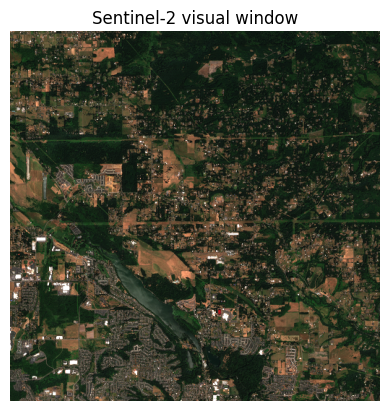

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rgb = np.transpose(array.data, (1, 2, 0))
plt.imshow(rgb)
plt.title("Sentinel-2 visual window")
plt.axis("off")

## Visualize the full scene with Lonboard

For an interactive map view of the same item, stream the scene's COG tiles through the Planetary Computer tiler into a Lonboard `BitmapTileLayer`.

**Expected result:** an interactive map of the Sentinel-2 scene that pans and zooms.

In [8]:
import json
import urllib.request

from lonboard import BitmapTileLayer, Map

tilejson = json.load(urllib.request.urlopen(
    "https://planetarycomputer.microsoft.com/api/data/v1/item/tilejson.json"
    f"?collection={item.collection_id}&item={item.id}&assets=visual"
))
lon, lat, _ = tilejson["center"]
layer = BitmapTileLayer(
    data=tilejson["tiles"][0],
    min_zoom=int(tilejson["minzoom"]),
    max_zoom=int(tilejson["maxzoom"]),
    tile_size=256,
)
Map(layer, view_state={"longitude": lon, "latitude": lat, "zoom": 11})

## Read many windows in parallel

Each `read()` is independent. Fire 64 of them at once and let async-geotiff issue range requests in parallel and decode them on the Rust thread pool.

**Expected result:** 64 arrays, each shape `(3, 256, 256)`.

In [ ]:
import asyncio

windows = [
    Window(c, r, 256, 256)
    for c in range(0, 2048, 256)
    for r in range(0, 2048, 256)
]
arrays = await asyncio.gather(
    *[geotiff.overviews[0].read(window=w) for w in windows]
)
len(arrays), arrays[0].data.shape

## You're done

If every cell above produced its expected result, async-geotiff is wired up end-to-end:

- **No GDAL**: pip-installed, no system deps
- **Async-first**: 64 parallel window reads in one `gather`
- **Zero-copy**: array data is a NumPy view onto the decoded buffer
- **Type-hinted**: full autocomplete on `GeoTIFF`, `Window`, `Array`
- **Overview-aware**: picked overview `[0]` for full resolution explicitly

For resampling or reprojection, hand the array to [rasterio](https://rasterio.readthedocs.io/) via an in-memory file. For browser-side rendering of the same data, see the [Lonboard tutorial](../overview/lonboard.md) or the [deck.gl-raster tutorial](../overview/deckgl-raster.md).